Ouvrir ce notebook dans :
<a href="https://colab.research.google.com/github/joanglaunes/algosto/blob/master/python/Controle_1_2025.ipynb" target="_blank">Google Colab</a>
ou
<a href="https://rosenblatt.ens.math-info.univ-paris5.fr/hub/user-redirect/git-pull?repo=https%3A%2F%2Fgithub.com%2Fjoanglaunes%2Falgosto&urlpath=tree%2Falgosto%2Fpython%2FControle_1_2025.ipynb&branch=master" target="_blank">Rosenblatt</a>

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [12]:
# Exercice 1, question 2

# exemple de fonction simul_X pour tester : X de loi uniforme sur [0,1]
def simul_X():
    return np.random.rand()

niter = 1000
u = 0
for t in range(niter):
   x = simul_X()    # tirage au sort selon la loi de X
   g = 2*(u-x)      # gradient de la fonction u -> (x-u)^2
   eta = 1/(1+t)    # pas de descente
   u = u - eta * g  # mise à jour de u

print(u)  # doit être proche de E(X)=0.5

0.5067954293615586


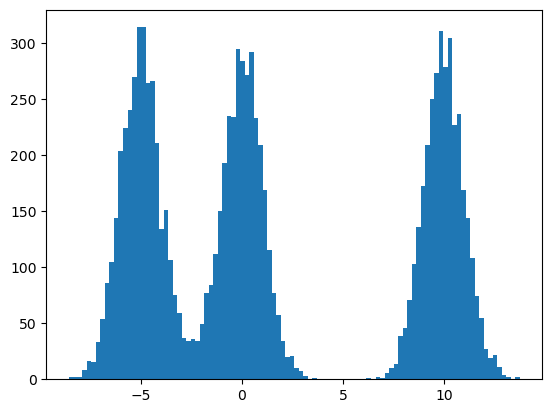

In [16]:
# Exercice 2, question 2

def simul_melange(m,n):
   K = len(m)
   z = np.random.choice(K,size=n)
   x = np.zeros(n)
   for k in range(K):
      x[z==k] = np.random.randn(sum(z==k)) + m[k]
   return x

m = np.array([-5,0,10])
K = len(m)
x = simul_melange(m,10000)
n = len(x)
plt.hist(x,100);

In [22]:
# Exercice 2, question 3 : on teste l'algo EM pour vérifier que ça fonctionne

mu = np.random.rand(K)   # initialisation des mu_k
gamma = np.zeros((n,K))
for t in range(1000):
    # étape E
    for k in range(K):
        gamma[:,k] = scipy.stats.norm.pdf(x,loc=mu[k])
    gamma /= np.sum(gamma,axis=1,keepdims=True)
    # étape M
    mu = np.sum(x[:,None]*gamma,axis=0) / np.sum(gamma,axis=0)
print(f"mu={mu}, m={m}") # les coefficents de mu et m doivent être proches (mais l'ordre est quelconque)

mu=[ 9.9805843  -5.00855419  0.01970637], m=[-5  0 10]


In [27]:
# Exercice 2, question 7 : on teste l'algo de gradient stochastique pour vérifier que ça fonctionne

mu = np.random.rand(K)   # initialisation des mu_k
eta = lambda t : 1/(1+.01*t)
gamma = np.zeros(K)
for t in range(1000):
    i = np.random.choice(n)
    for k in range(K):
        gamma[k] = scipy.stats.norm.pdf(x[i],loc=mu[k])
    gamma /= np.sum(gamma)
    g = gamma*(mu-x[i])
    mu -= eta(t)*g
print(f"mu={mu}, m={m}") # les coefficents de mu et m doivent être proches (mais l'ordre est quelconque)

mu=[-5.16195954 -0.09298236 10.04360641], m=[-5  0 10]
